### **MSER Segmentation Pipeline**

#### Import Packages

In [1]:
import cv2
import numpy as np
from dataloader import MOVE
import os
import random


import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import scipy
from scipy.spatial import distance
from scipy.ndimage import gaussian_filter1d

import math

#### Global Variables

In [2]:
RANDOM_SAMPLE = False
X_ONCLICK = 0
Y_ONCLICK = 0

#### Helper Functions

In [3]:
# either generates a random path, or uses a video that you choose

def generate_path(rando : bool) -> str:
    if rando==True:
        ROOT = os.path.dirname(os.getcwd())
        DATA_DIR = os.path.join(ROOT, 'data')
        FIN_DIR = os.path.join(DATA_DIR, random.choice(list(filter(lambda x: os.path.isdir(os.path.join(DATA_DIR, x)), os.listdir(DATA_DIR)))))
        vp = os.path.join(FIN_DIR, random.choice(list(filter(lambda x: os.path.splitext(x)[1]=='.mov', os.listdir(FIN_DIR)))))
    else:
        # 1/32" tester
        #vp = r'C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\TH32\TH32ST17A3D1000TS0_2.mov'

        # 1/16" tester
        #vp = r'C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\TH16\TH16ST25A3D500TS0_2.mov'

        # 3/32" tester (boring)
        #vp = r'C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\TH332\TH332ST25A3D750TS0_2.mov'

        # 3/32" tester (bubbly)
        vp = r'C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\TH332\TH332ST17A3D1000TS0_2.mov'

        # 1/8" tester
        #vp = r'C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\TH8\TH8ST17A3D1000TS0_2.mov'
    print(vp)

    return vp

In [4]:
# some video helper functions - play two videos stacked vertically, play a series of frames that's not a MOVE object, or
# create a linear bounding box based on contours and overlay it onto an image

def compare_videos(frames1, frames2, crop = None, doubletime = False, slow = False, ultraslow = False):
    divider = 255 * np.ones((10, frames1[0].shape[1]))
    frames = []

    if len(frames1) != len(frames2):
        frames1 = frames1[:min([len(frames1), len(frames2)])]
        frames2 = frames2[:min([len(frames1), len(frames2)])]

    for i in range(len(frames1)):
        frame1 = frames1[i][:crop, :]
        frame2 = frames2[i][:crop, :]
        joined = np.concat((frame1, divider, frame2), axis = 0)
        frames.append(joined)
    
    for frame in frames:
            cv2.imshow("Video Frame", frame)
            if doubletime:
                if cv2.waitKey(12) & 0xFF == ord('q'):
                    break
            elif slow:
                if cv2.waitKey(40) & 0xFF == ord('q'):
                    break
            elif ultraslow:
                if cv2.waitKey(60) & 0xFF == ord('q'):
                    break
            else:
                if cv2.waitKey(25) & 0xFF == ord('q'):
                    break
                 
        
    cv2.destroyAllWindows()

def play_video(frames, doubletime=False, slow=False, ultraslow=False):
    for frame in frames:
        cv2.imshow("Video Frame", frame)
        if doubletime:
            if cv2.waitKey(12) & 0xFF == ord('q'):
                break
        elif slow:
            if cv2.waitKey(40) & 0xFF == ord('q'):
                break
        elif ultraslow:
            if cv2.waitKey(60) & 0xFF == ord('q'):
                break
        else:
            if cv2.waitKey(25) & 0xFF == ord('q'):
                break
                 
    cv2.destroyAllWindows()


# for waterline detection - when image is clicked, stores coordinates

def click_event(event, x, y, flags, param):
    global X_ONCLICK
    global Y_ONCLICK
    if event == cv2.EVENT_LBUTTONDOWN:
        X_ONCLICK = x
        Y_ONCLICK = y
        cv2.destroyAllWindows()
        return
    else:
        return
    

# given 2 bounding boxes, b and a, return whether b is in a

def isin(a, b):
    if a[0] <= b[0] and a[1] <= b[1]:
            if (a[0] + a[2]) >= (b[0] + b[2]):
                if (a[1] + a[3]) >= (b[1] + b[3]):
                    return True
    return False

### **MSER detection and tracking**

#### Load video

In [5]:
# video loading, convert to grayscale, create copy to work with

vid_path = generate_path(False)
recording = MOVE(vid_path)
recording.to_gray(inplace=True)
#recording.play_video()

C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\TH332\TH332ST17A3D1000TS0_2.mov


#### Find waterline and crop

In [6]:
# find waterline (with user input) and crop below waterline

background = recording.get_avg()
background = cv2.GaussianBlur(background, (1111, 1), sigmaX=32000, borderType=cv2.BORDER_REFLECT)

Z = np.float32(background.reshape((-1, 3)))

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
quantized = centers[labels.flatten()]
quantized = quantized.reshape(background.shape)

cv2.imshow("Click on waterline.", quantized)
cv2.setMouseCallback("Click on waterline.", click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()
print(X_ONCLICK, Y_ONCLICK)

cropped = recording.crop(row_start = Y_ONCLICK)
#play_video(cropped.frames, doubletime=True)

630 546


In [117]:
cropped.remove_avg(skipframes=100)
#play_video(cropped.frames, doubletime=True)

#### **Get fin removal mask**

In [119]:
# binarize image (or just crank the contrast super high? idk)

dupe = recording.change_contrast(alpha=2, beta=-10, inplace=False)
dupe.remove_avg(skipframes=100)
binary:MOVE = dupe.ranger(minval=50, maxval=240)
binary.median_blur(inplace=True)
binary = binary.crop(row_start = Y_ONCLICK)
#play_video(binary, doubletime=True)

In [75]:
play_video(binary, doubletime=True)

In [120]:
# remove the fin and smaller bubbles

fin_removed = binary.copy()
fin_removed = fin_removed.fin_removal(ksize = (3, 12))
fin_removed = fin_removed.dilate(kernel=cv2.MORPH_RECT, ksize=(30, 30))
fin_removed = fin_removed.hole_filler()
play_video(fin_removed, doubletime=True)

In [121]:
# mask grayscale video with fin-removed binary image

masked = cropped.bitwise_and(fin_removed)
masked = MOVE(frames=masked)
masked = masked.median_blur(ksize=5)
#play_video(masked)

#### **Detect and display MSERs**

In [122]:
# construct MSER detector and detect regions

mser = cv2.MSER_create(delta = 5, min_area = 200, max_area = 30000)

In [123]:
(display_msers, bboxes) = masked.mser_track(mser=mser, vert_threshold=0.35, area_threshold=0.3)

In [85]:
play_video(display_msers)

In [103]:
def bbox_overlay(video, bboxes, vert_offset=0, color=(244, 255, 41), width=1):
    for i in range(len(video.frames)):
        frame = video.frames[i]
        for bbox in bboxes[i]:
            x, y, w, h = bbox
            cv2.rectangle(frame, (x, y + vert_offset), (x + w, y + vert_offset + h), color, width)

    return video

In [124]:
og_vid = MOVE(vid_path)
cropped = og_vid.crop(row_start=Y_ONCLICK)
cropped = bbox_overlay(cropped, bboxes, color = (84, 121, 255), width=2)

In [125]:
play_video(cropped, slow=True)

In [126]:
def params_by_frame(bboxes):
    widths = []
    depths = []

    for frame in bboxes:
        if len(frame) > 0:
            left = []
            right = []
            top = []
            bottom = []
            for bbox in frame:
                x, y, w, h = bbox
                left.append(x)
                right.append(x + w)
                top.append(y)
                bottom.append(y + h)
            width = max(right) - min(left)
            depth = max(bottom) - min(top)
            widths.append(width)
            depths.append(depth)
        else:
            widths.append(-1)
            depths.append(-1)
    return widths, depths 

In [127]:
widths, depths = params_by_frame(bboxes)
frames = np.arange(len(widths))
filtered_widths = gaussian_filter1d(widths, sigma=2, radius=2)
filtered_depths = gaussian_filter1d(depths, sigma=2, radius=2)

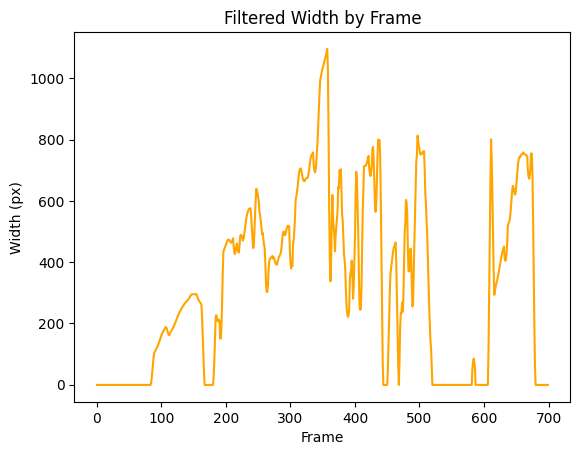

In [128]:
#plt.plot(frames, widths)
plt.plot(frames, filtered_widths, color='orange')
plt.title("Filtered Width by Frame")
plt.xlabel("Frame")
plt.ylabel("Width (px)")
plt.show()

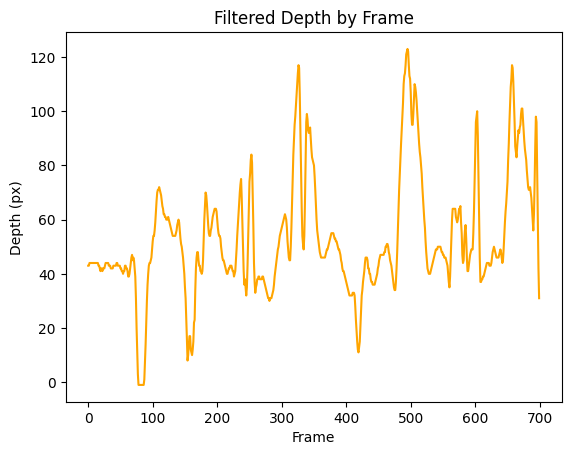

In [113]:
#plt.plot(frames, depths)
plt.plot(frames, filtered_depths, color='orange')
plt.title("Filtered Depth by Frame")
plt.xlabel("Frame")
plt.ylabel("Depth (px)")
plt.show()

In [ ]:
# test frame loading and processing

test_frame = masked.frames[300].copy()

for i in range(0, 25):
    scale = 1.75 * math.cos((3.1/50) * i) + 1
    test_frame[i] = cv2.convertScaleAbs(test_frame[i], alpha=scale, beta=0).reshape(1264,)

#test_frame = np.concatenate((test_top, test_frame[25:]), axis=0)
#test_frame = cv2.medianBlur(test_frame, ksize=5)

test_frame = cv2.convertScaleAbs(test_frame, alpha = 1.5, beta = 20)
MOVE.show(test_frame)

In [ ]:
# detect MSERs

(msers, bboxes) = mser.detectRegions(test_frame)
print(len(msers))
print(msers[0])
print(bboxes[0])


206
[584  70  18  21]


In [17]:
# remove nested bounding boxes

i = 0

while i < len(bboxes):
    j = 0
    to_delete = []
    decrement = 0

    while j < len(bboxes) and i < len(bboxes):
        if i != j and isin(bboxes[i], bboxes[j]):
            to_delete.append(j)
            if j < i:
                decrement += 1
        j += 1
    
    bboxes = np.delete(bboxes, to_delete, axis=0)
    i += (1 - decrement)

In [18]:
# display MSER bounding boxes

test_frame = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)

if len(bboxes) > 0:
    for b in bboxes:
        x, y, w, h = b
        cv2.rectangle(test_frame, (x, y), (x + w, y + h), (244, 255, 41), 1)

MOVE.show(test_frame)